# *0. Ознакомиться с [блокнотом](https://colab.research.google.com/drive/1PwN8igT5w2xArBGmM6rvO9pVRQMh-FQn?usp=sharing)

# 1. Дерево решений для классификации

In [41]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [42]:
# !wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

In [43]:
# На  локальной машине
!gdown 1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G -O cardio.csv

Downloading...
From: https://drive.google.com/uc?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
To: c:\Users\user\Desktop\6prac\cardio.csv

  0%|          | 0.00/2.94M [00:00<?, ?B/s]
 36%|███▌      | 1.05M/2.94M [00:00<00:00, 9.20MB/s]
 89%|████████▉ | 2.62M/2.94M [00:00<00:00, 10.7MB/s]
100%|██████████| 2.94M/2.94M [00:00<00:00, 10.6MB/s]


В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [44]:
import pandas as pd
df = pd.read_csv('cardio.csv', sep = ';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [45]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [46]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [47]:
print(sum(df[full_features].nunique() - 1))

737


### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [48]:
features=['weight', 'gluc']
X_sub = df[['weight', 'gluc']].head(10)
y_sub = df[target].head(10)

### 1.3 Посчитайте еще раз, сколько будет вопросов

In [49]:
print(f'Вопросов будет: {sum(X_sub.nunique() - 1)}')

Вопросов будет: 11


С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [50]:
tree_clf = DecisionTreeClassifier(random_state=1)
tree_clf.fit(X_sub, y_sub)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

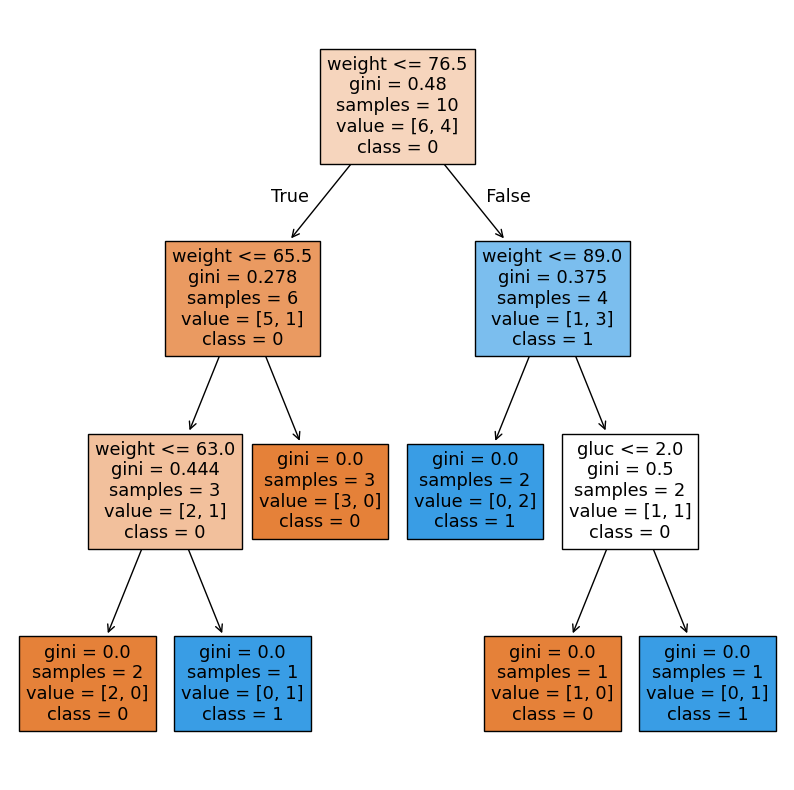

In [51]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plot_tree(tree_clf, feature_names=['weight', 'gluc'], class_names=['0', '1'], filled=True)
plt.show()

### 2.3 Посчитайте, сколько вершин получилось

In [52]:
print(tree_clf.tree_.node_count)

11


### 2.4 Посчитайте, сколько листов получилось

In [53]:
print(tree_clf.tree_.n_leaves)

6


### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

Невозможно из-за того, что уже недостаточно образцов, которые нужно было бы разделять, остается только разбить на два окончательных листа

## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

In [54]:
def gini(y):
    if len(y) == 0:
        return 0
    probs = [sum(y == c) / len(y) for c in set(y)]
    return 1 - sum(p**2 for p in probs)

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [55]:
print(gini(y_sub))

0.48


### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

In [56]:
def ig(left, right, root):
  res = gini(root) - ((len(left)/len(root))*gini(left)+(len(right)/len(root))*gini(right))
  return res

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [57]:
import numpy as np
results=[]
for feature in X_sub.columns:
  question_vals = []
  vals = X_sub[feature].values
  vals.sort
  vals = np.unique(vals)
  for i in range(len(vals)-1):
    question_vals.append((vals[i]+vals[i+1])/2)
  for i in question_vals:
    y_left = y_sub[X_sub[feature] <= i]
    y_right = y_sub[X_sub[feature] > i]
    info_gain = ig(y_left, y_right, y_sub)
    results.append({
    'Признак': feature,
    'Вопрос': i,
    'Прирост информации': info_gain,
    'Кол-во образцов слева': len(y_left),
    'Кол-во образцов справа': len(y_right)
    })

results = pd.DataFrame(results)
results

,Признак,Вопрос,Прирост информации,Кол-во образцов слева,Кол-во образцов справа
0,weight,59.0,0.035556,1,9
1,weight,63.0,0.080000,2,8
2,weight,65.5,0.003810,3,7
3,weight,67.5,0.030000,4,6
4,weight,69.5,0.080000,5,5
5,weight,76.5,0.163333,6,4
6,weight,83.5,0.060952,7,3
7,weight,89.0,0.005000,8,2
8,weight,94.0,0.080000,9,1
9,gluc,1.5,0.005000,8,2


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [58]:
results.sort_values('Прирост информации', ascending=False, inplace=True)
results

,Признак,Вопрос,Прирост информации,Кол-во образцов слева,Кол-во образцов справа
5,weight,76.5,0.163333,6,4
4,weight,69.5,0.080000,5,5
10,gluc,2.5,0.080000,9,1
8,weight,94.0,0.080000,9,1
1,weight,63.0,0.080000,2,8
6,weight,83.5,0.060952,7,3
0,weight,59.0,0.035556,1,9
3,weight,67.5,0.030000,4,6
7,weight,89.0,0.005000,8,2
9,gluc,1.5,0.005000,8,2


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [59]:
question = results[['Признак','Вопрос']].iloc[0]
df_left = pd.DataFrame(X_sub[X_sub[question.iloc[0]] <= question.iloc[1]])
df_right = pd.DataFrame(X_sub[X_sub[question.iloc[0]] > question.iloc[1]])
display(df_left)
display(df_right)

,weight,gluc
0,62.0,1
2,64.0,1
4,56.0,1
5,67.0,2
8,71.0,1
9,68.0,1


,weight,gluc
1,85.0,1
3,82.0,1
6,93.0,1
7,95.0,3


4.1.4. Проверьте себя через визуализацию дерева решений

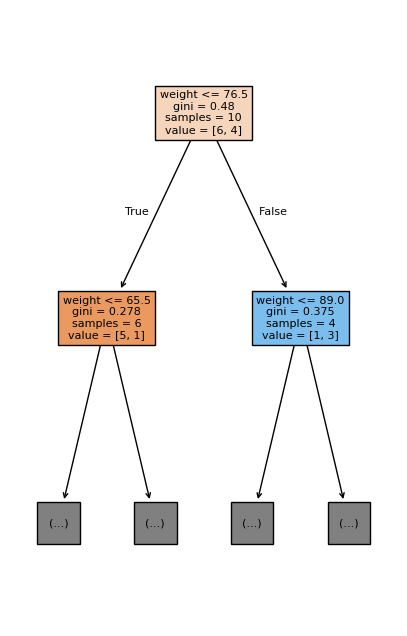

In [60]:
plt.figure(figsize=(5, 8))
plot_tree(tree_clf, feature_names=features, filled=True, max_depth=1)
plt.show()

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

Разбиение лучше всего проводить по признаку weight, т.к. он наиболее разнообразный. Выберем для разбиения левый узел, т.к. в нем наибольшее кол-во образов

4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [61]:
results2=[]
for feature in df_left.columns:
  question_vals = []
  vals = df_left[feature].values
  vals.sort
  vals = np.unique(vals)
  for i in range(len(vals)-1):
    question_vals.append((vals[i]+vals[i+1])/2)
  for i in question_vals:
    y_left = y_sub[df_left.index][df_left[feature] <= i]
    y_right = y_sub[df_left.index][df_left[feature] > i]
    info_gain = ig(y_left, y_right, y_sub[df_left.index])
    results2.append({
    'Признак': feature,
    'Вопрос': i,
    'Прирост информации': info_gain,
    'Кол-во образцов слева': len(y_left),
    'Кол-во образцов справа': len(y_right)
    })

results2 = pd.DataFrame(results2)
results2

,Признак,Вопрос,Прирост информации,Кол-во образцов слева,Кол-во образцов справа
0,weight,59.0,0.011111,1,5
1,weight,63.0,0.027778,2,4
2,weight,65.5,0.055556,3,3
3,weight,67.5,0.027778,4,2
4,weight,69.5,0.011111,5,1
5,gluc,1.5,0.011111,5,1


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [62]:
results2.sort_values('Прирост информации', ascending=False, inplace=True)
results2

,Признак,Вопрос,Прирост информации,Кол-во образцов слева,Кол-во образцов справа
2,weight,65.5,0.055556,3,3
1,weight,63.0,0.027778,2,4
3,weight,67.5,0.027778,4,2
0,weight,59.0,0.011111,1,5
4,weight,69.5,0.011111,5,1
5,gluc,1.5,0.011111,5,1


4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [63]:
question2 = results2[['Признак','Вопрос']].iloc[0]
df_left2 = pd.DataFrame(df_left[df_left[question2.iloc[0]] <= question2.iloc[1]])
df_right2 = pd.DataFrame(df_left[df_left[question2.iloc[0]] > question2.iloc[1]])
display(df_left2)
display(df_right2)

,weight,gluc
0,62.0,1
2,64.0,1
4,56.0,1


,weight,gluc
5,67.0,2
8,71.0,1
9,68.0,1


4.2.5. Проверьте себя через визуализацию дерева решений

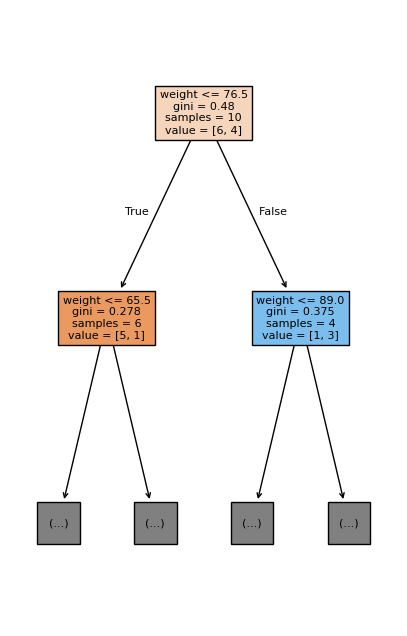

In [64]:
plt.figure(figsize=(5, 8))
plot_tree(tree_clf, feature_names=features, filled=True, max_depth=1)
plt.show()

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

Всё получилось достойно

# 2. Дерево решений для регрессии

In [65]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

### 1. Получение данных load_breat_cancer

Будем работать с набором данных для задачи регрессии `load_diabetes`, который можно получить из стандартных датасетов в `sklearn'e`.

После `load_diabetes()` возвращается словарь с данными (`data`), целевой переменной (`target`), названиями характеристик в данных (`feature_names`) и описанием данных (`DESCR`).

In [66]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [67]:
X = data.data
features = data.feature_names
y = data.target

Из признаков (характеристик данных) и целевой переменной сформируем датафрейм, в качестве названий колонок возьмем названия признаков.

In [68]:
df = pd.DataFrame(X, columns=features)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Разобьем выборку на две: обучающую и тестовую.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((353, 10), (353,), (89, 10), (89,))

### 1.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [70]:
tree_reg = DecisionTreeRegressor(random_state=1)
tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

### 1.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [71]:
from sklearn.metrics import mean_squared_error, r2_score
y_train_pred = tree_reg.predict(X_train)
y_test_pred = tree_reg.predict(X_test)
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Train MSE: 0.0
Train R2: 1.0
Test MSE: 5897.134831460674
Test R2: -0.08909766517566808


Сделайте вывод, насколько хорошо обучилась модель

Модель слишком сильно переобучилась, так как показывает на обучающей выборке идеальные результаты, а на тестовой оказывается хуже случайного угадывания

### 1.3. Изменение метрики

Попробуйте поизменять известные параметры для того, чтобы метрика стала лучше.

In [72]:
tree = DecisionTreeRegressor(random_state=1, max_depth=4, min_samples_split=60, max_leaf_nodes=7)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)
r2_tr = r2_score(y_train, train_pred)
mse_tr = mean_squared_error(y_train, train_pred)
r2_ts = r2_score(y_test, test_pred)
mse_ts = mean_squared_error(y_test, test_pred)
print(f"R2 обучающая: {r2_tr}; R2 тестовая: {r2_ts}")
print(f"MSE обучающая: {mse_tr}; MSE тестовая: {mse_ts}")

R2 обучающая: 0.5055480645811378; R2 тестовая: 0.4062190613840273
MSE обучающая: 2991.2448550130916; MSE тестовая: 3215.1443964438827


Оптимальные значения:

max depth: >=4 (уменьшение - ухудшает результат, увеличение - не изменяет) ;
min_samples_split: <=60 (увеличение приводит к ухудшению результата, уменьшение никак не влияет) ;
max_leaf_nodes: 7 (увеличение не изменяет результат, уменьшение - ухудшает) ;

### 2. Получение данных make_regression

Для второго примера возьмем самодельный набор данных для задачи регрессии `make_regression`, который можно получить из стандартных датасетов в `sklearn'e`.

Сгенерируем себе 100к объектов, которые описываются 20 признаками, из них 12 будут дейтсвительно полезными.

In [73]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100_000, n_features=20, n_informative=12, random_state=10)

In [74]:
X.shape, y.shape

((100000, 20), (100000,))

Разобьем выборку на две: обучающую и тестовую.

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80000, 20), (80000,), (20000, 20), (20000,))

### 2.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [76]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=1)
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

### 2.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [77]:
from sklearn.metrics import r2_score, mean_squared_error

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)
r2_tr = r2_score(y_train, train_pred)
mse_tr = mean_squared_error(y_train, train_pred)
r2_ts = r2_score(y_test, test_pred)
mse_ts = mean_squared_error(y_test, test_pred)
print(f"R2 обучающая: {r2_tr}; R2 тестовая: {r2_ts}")
print(f"MSE обучающая: {mse_tr}; MSE тестовая: {mse_ts}")

R2 обучающая: 1.0; R2 тестовая: 0.6915358863274659
MSE обучающая: 0.0; MSE тестовая: 16653.348146704826


Сделайте вывод, насколько хорошо обучилась модель

Сделайте вывод, насколько хорошо обучилась модель

Модель обучилась достаточно хорошо, хоть и выдает признаки переобучения (идеальный результат на обучении)

### 2.3. Перебор гиперпараметров

Осуществите перебор параметров для получения лучших результатов (GridSearchCV, см. подход из п.0).

In [78]:
from sklearn.model_selection import GridSearchCV
tree_params = {"max_depth": range(1, 15), "min_samples_split": range(2,15)} 
# Перебираю до 15 каждый гиперпараметр, время выполнения на моей машине: ~1 минуты
# Не использую max_leaf_nodes, так как в сочетании с max_depth даст нерентабельно маленькое улучшение (а также, когда я попробовал, она обучалась ~22 минуты и упала с ошибкой)
# min_samples_split начинается с 2-ки, так как нет смысла раздувать модель
tree_grid = GridSearchCV(tree, tree_params, cv=5, n_jobs=-1)
tree_grid.fit(X_train, y_train)

print(tree_grid.best_params_)
print(tree_grid.best_score_)

{'max_depth': 14, 'min_samples_split': 14}
0.7149551893450472


Самые лучшие результаты наблюдались при попытке изменить гиперпараметр max_depth и min_samples_split (в данном случае max_leaf_nodes остаются заданным функцией по умолчанию, а max_depth = 14 и min_samples_split = 14). Изменять большее количество параметров не удавалось из-за ошибок возникших при переборе.